<a href="https://colab.research.google.com/github/Vino8801/Comprehensive-Analysis-of-Lung-Cancer-Mortality-and-Influencing-Factors-in-Europe/blob/main/ML_Model_Project_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data=pd.read_csv("/content/drive/MyDrive/Lu.cancer.csv")
print(data)


             id  age  gender         country diagnosis_date cancer_stage  \
0             1   64  Female         Germany     07/04/2016    Stage III   
1             2   50    Male  Czech Republic     22/04/2023    Stage III   
2             3   65    Male         Romania     07/04/2023     Stage IV   
3             4   51  Female          Latvia     07/02/2016    Stage III   
4             5   37    Male          Greece     01/12/2023      Stage I   
...         ...  ...     ...             ...            ...          ...   
999995   999996   56    Male          Cyprus     08/11/2018     Stage II   
999996   999997   55    Male          France     21/07/2014    Stage III   
999997   999998   49    Male         Romania     21/02/2021     Stage IV   
999998   999999   61    Male         Austria     23/10/2014     Stage II   
999999  1000000   53  Female        Slovenia     04/02/2021      Stage I   

       beginning_of_treatment_date family_history  smoking_status   bmi  \
0           

In [ ]:
data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})
data['cancer_stage'] = data['cancer_stage'].map({'Stage I': 1, 'Stage II': 2, 'Stage III':3, 'Stage IV':4})
data['treatment_type'] = data['treatment_type'].map({'Chemotherapy': 1, 'Combined': 2, 'Radiation':3, 'Surgery':4})
data['smoking_status'] = data['smoking_status'].map({'Current Smoker': 1, 'Former Smoker': 2, 'Never Smoked':3, 'Passive Smoker':4})
data['family_history'] = data['family_history'].map({'Yes': 1, 'No': 0})

In [ ]:
# Import necessary libraries
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define your features (X) and target variable (y)
X = data[['age', 'gender', 'cancer_stage', 'family_history', 'smoking_status', 'bmi', 'cholesterol_level', 'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type']]
y = data['survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


# Check the distribution of the resampled training data
print("Training set after SMOTE:")
print(y_train_res.value_counts())

# Check the distribution of the original testing data
print("\nTesting set distribution:")
print(y_test.value_counts())


Training set after SMOTE:
survived
1    624823
0    624823
Name: count, dtype: int64

Testing set distribution:
survived
0    155718
1     44282
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


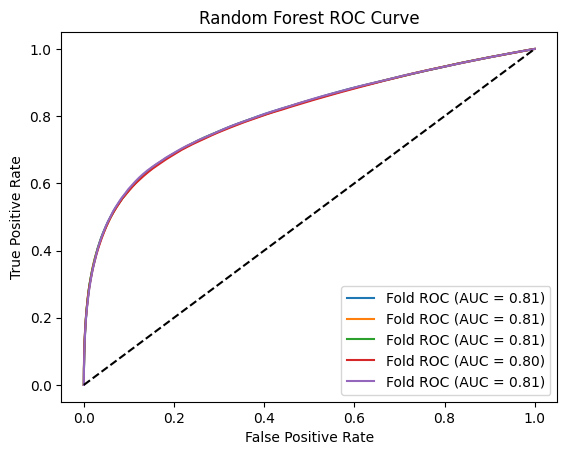

Random Forest Average Accuracy: 0.73
Random Forest Average ROC AUC: 0.81
Random Forest Average Precision: 0.73
Random Forest Average Recall: 0.74
Random Forest Average F1-Score: 0.73
Random Forest Confusion Matrix:
[[449060 175763]
 [160282 464541]]


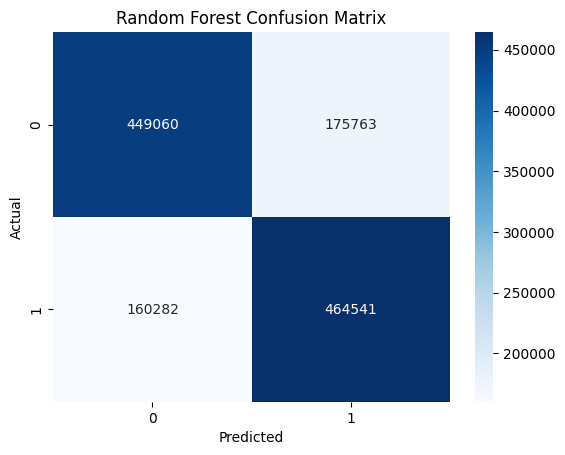

In [ ]:
# Initialize StratifiedKFold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store results
rf_accuracy = []
rf_roc_auc = []
rf_precision = []
rf_recall = []
rf_f1 = []
rf_conf_matrix = np.array([[0, 0], [0, 0]])

# Loop through the folds
for train_index, test_index in kf.split(X_train_res, y_train_res):
    X_train_fold, X_val_fold = X_train_res.iloc[train_index], X_train_res.iloc[test_index]
    y_train_fold, y_val_fold = y_train_res.iloc[train_index], y_train_res.iloc[test_index]

    # Initialize and train the RandomForestClassifier
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train_fold, y_train_fold)

    # Predict the labels
    y_pred = rf.predict(X_val_fold)
    y_pred_prob = rf.predict_proba(X_val_fold)[:, 1]

    # Append metrics for this fold
    rf_accuracy.append(accuracy_score(y_val_fold, y_pred))
    rf_roc_auc.append(roc_auc_score(y_val_fold, y_pred_prob))
    rf_precision.append(precision_score(y_val_fold, y_pred))
    rf_recall.append(recall_score(y_val_fold, y_pred))
    rf_f1.append(f1_score(y_val_fold, y_pred))

    # Update the confusion matrix
    rf_conf_matrix += confusion_matrix(y_val_fold, y_pred)

    # Plot ROC curve for each fold
    fpr, tpr, _ = roc_curve(y_val_fold, y_pred_prob)
    plt.plot(fpr, tpr, label=f'Fold ROC (AUC = {roc_auc_score(y_val_fold, y_pred_prob):.2f})')

# Plot settings for ROC curve
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc='best')
plt.show()

# Calculate and print average metrics
print(f'Random Forest Average Accuracy: {np.mean(rf_accuracy):.2f}')
print(f'Random Forest Average ROC AUC: {np.mean(rf_roc_auc):.2f}')
print(f'Random Forest Average Precision: {np.mean(rf_precision):.2f}')
print(f'Random Forest Average Recall: {np.mean(rf_recall):.2f}')
print(f'Random Forest Average F1-Score: {np.mean(rf_f1):.2f}')
print(f'Random Forest Confusion Matrix:\n{rf_conf_matrix}')

# Plot the Confusion Matrix
sns.heatmap(rf_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


[LightGBM] [Info] Number of positive: 499858, number of negative: 499858
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.311710 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 517
[LightGBM] [Info] Number of data points in the train set: 999716, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 499858, number of negative: 499859
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.126591 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 517
[LightGBM] [Info] Number of data points in the train set: 999717, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499999 -> initscore

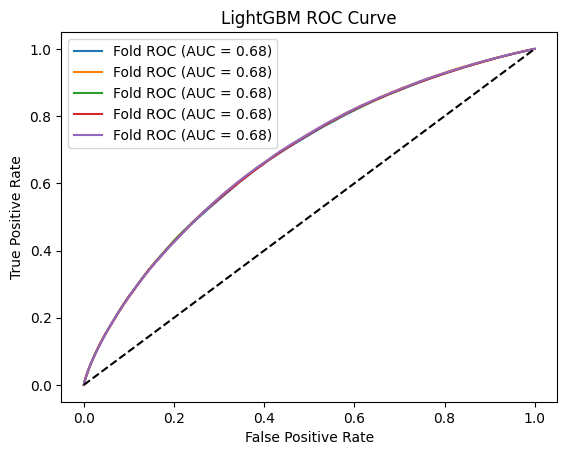

LightGBM Average Accuracy: 0.63
LightGBM Average ROC AUC: 0.68
LightGBM Average Precision: 0.63
LightGBM Average Recall: 0.63
LightGBM Average F1-Score: 0.63
LightGBM Confusion Matrix:
[[392208 232615]
 [228987 395836]]


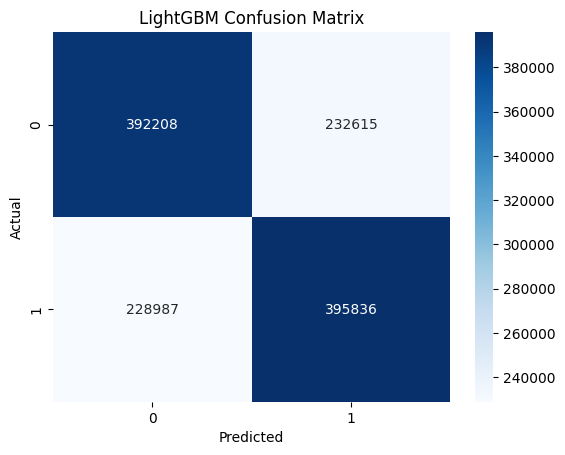

In [ ]:
# Initialize lists to store results
lgb_accuracy = []
lgb_roc_auc = []
lgb_precision = []
lgb_recall = []
lgb_f1 = []
lgb_conf_matrix = np.array([[0, 0], [0, 0]])

# Loop through the folds
for train_index, test_index in kf.split(X_train_res, y_train_res):
    X_train_fold, X_val_fold = X_train_res.iloc[train_index], X_train_res.iloc[test_index]
    y_train_fold, y_val_fold = y_train_res.iloc[train_index], y_train_res.iloc[test_index]

    # Initialize the LGBMClassifier
    lgb = LGBMClassifier(random_state=42)

    # Train the model
    lgb.fit(X_train_fold, y_train_fold)

    # Predict the labels
    y_pred = lgb.predict(X_val_fold)
    y_pred_prob = lgb.predict_proba(X_val_fold)[:, 1]

    # Append metrics for this fold
    lgb_accuracy.append(accuracy_score(y_val_fold, y_pred))
    lgb_roc_auc.append(roc_auc_score(y_val_fold, y_pred_prob))
    lgb_precision.append(precision_score(y_val_fold, y_pred))
    lgb_recall.append(recall_score(y_val_fold, y_pred))
    lgb_f1.append(f1_score(y_val_fold, y_pred))

    # Update the confusion matrix
    lgb_conf_matrix += confusion_matrix(y_val_fold, y_pred)

    # Plot ROC curve for each fold
    fpr, tpr, _ = roc_curve(y_val_fold, y_pred_prob)
    plt.plot(fpr, tpr, label=f'Fold ROC (AUC = {roc_auc_score(y_val_fold, y_pred_prob):.2f})')

# Plot settings for ROC curve
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LightGBM ROC Curve')
plt.legend(loc='best')
plt.show()

# Calculate and print average metrics
print(f'LightGBM Average Accuracy: {np.mean(lgb_accuracy):.2f}')
print(f'LightGBM Average ROC AUC: {np.mean(lgb_roc_auc):.2f}')
print(f'LightGBM Average Precision: {np.mean(lgb_precision):.2f}')
print(f'LightGBM Average Recall: {np.mean(lgb_recall):.2f}')
print(f'LightGBM Average F1-Score: {np.mean(lgb_f1):.2f}')
print(f'LightGBM Confusion Matrix:\n{lgb_conf_matrix}')

# Plot the Confusion Matrix
sns.heatmap(lgb_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('LightGBM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [17:46:29] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [17:46:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [17:46:54] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [17:47:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [17:47:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

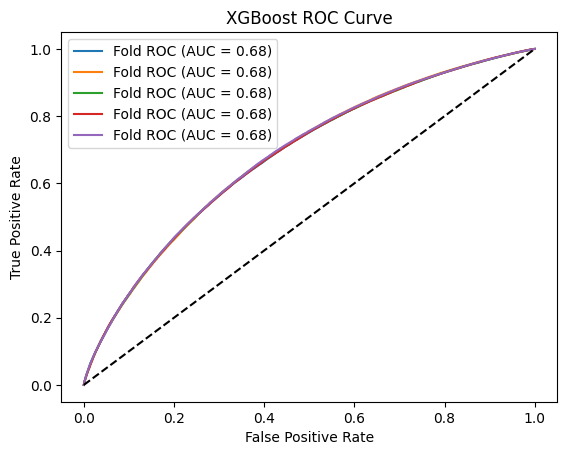

XGBoost Average Accuracy: 0.63
XGBoost Average ROC AUC: 0.68
XGBoost Average Precision: 0.63
XGBoost Average Recall: 0.64
XGBoost Average F1-Score: 0.64
XGBoost Confusion Matrix:
[[392874 231949]
 [224441 400382]]


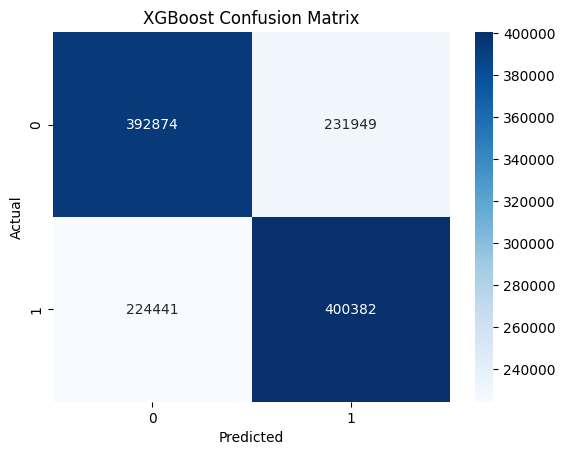

In [ ]:
# Initialize lists to store results
xgb_accuracy = []
xgb_roc_auc = []
xgb_precision = []
xgb_recall = []
xgb_f1 = []
xgb_conf_matrix = np.array([[0, 0], [0, 0]])

# Loop through the folds
for train_index, test_index in kf.split(X_train_res, y_train_res):
    X_train_fold, X_val_fold = X_train_res.iloc[train_index], X_train_res.iloc[test_index]
    y_train_fold, y_val_fold = y_train_res.iloc[train_index], y_train_res.iloc[test_index]

    # Initialize the XGBClassifier
    xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

    # Train the model
    xgb.fit(X_train_fold, y_train_fold)

    # Predict the labels
    y_pred = xgb.predict(X_val_fold)
    y_pred_prob = xgb.predict_proba(X_val_fold)[:, 1]

    # Append metrics for this fold
    xgb_accuracy.append(accuracy_score(y_val_fold, y_pred))
    xgb_roc_auc.append(roc_auc_score(y_val_fold, y_pred_prob))
    xgb_precision.append(precision_score(y_val_fold, y_pred))
    xgb_recall.append(recall_score(y_val_fold, y_pred))
    xgb_f1.append(f1_score(y_val_fold, y_pred))

    # Update the confusion matrix
    xgb_conf_matrix += confusion_matrix(y_val_fold, y_pred)

    # Plot ROC curve for each fold
    fpr, tpr, _ = roc_curve(y_val_fold, y_pred_prob)
    plt.plot(fpr, tpr, label=f'Fold ROC (AUC = {roc_auc_score(y_val_fold, y_pred_prob):.2f})')

# Plot settings for ROC curve
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend(loc='best')
plt.show()

# Calculate and print average metrics
print(f'XGBoost Average Accuracy: {np.mean(xgb_accuracy):.2f}')
print(f'XGBoost Average ROC AUC: {np.mean(xgb_roc_auc):.2f}')
print(f'XGBoost Average Precision: {np.mean(xgb_precision):.2f}')
print(f'XGBoost Average Recall: {np.mean(xgb_recall):.2f}')
print(f'XGBoost Average F1-Score: {np.mean(xgb_f1):.2f}')
print(f'XGBoost Confusion Matrix:\n{xgb_conf_matrix}')

# Plot the Confusion Matrix
sns.heatmap(xgb_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


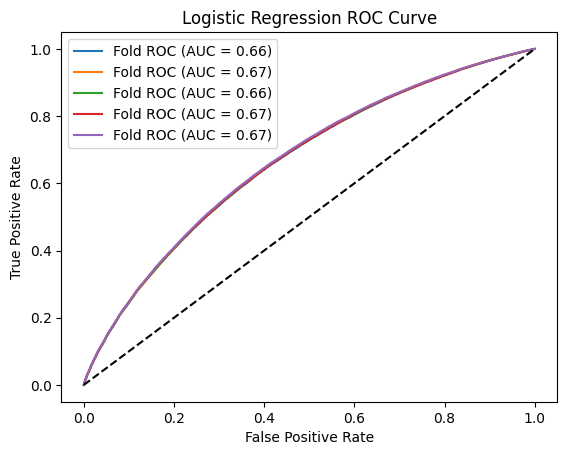

Logistic Regression Average Accuracy: 0.62
Logistic Regression Average ROC AUC: 0.67
Logistic Regression Average Precision: 0.62
Logistic Regression Average Recall: 0.65
Logistic Regression Average F1-Score: 0.63
Logistic Regression Confusion Matrix:
[[371794 253029]
 [219850 404973]]


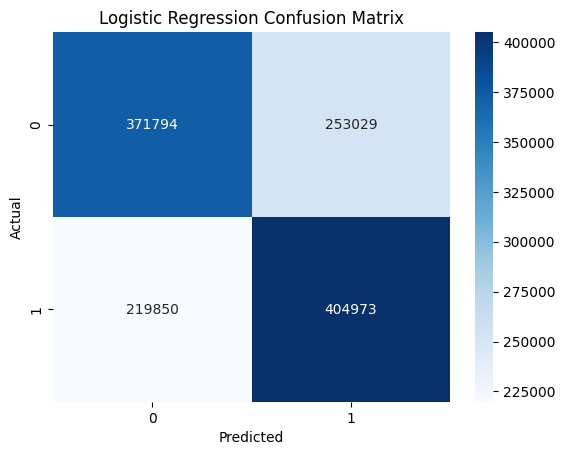

In [ ]:
# Initialize lists to store results
lr_accuracy = []
lr_roc_auc = []
lr_precision = []
lr_recall = []
lr_f1 = []
lr_conf_matrix = np.array([[0, 0], [0, 0]])

# Loop through the folds
for train_index, test_index in kf.split(X_train_res, y_train_res):
    X_train_fold, X_val_fold = X_train_res.iloc[train_index], X_train_res.iloc[test_index]
    y_train_fold, y_val_fold = y_train_res.iloc[train_index], y_train_res.iloc[test_index]

    # Initialize and train the model
    lr = LogisticRegression(random_state=42, max_iter=1000)
    lr.fit(X_train_fold, y_train_fold)

    # Predict
    y_pred = lr.predict(X_val_fold)
    y_pred_prob = lr.predict_proba(X_val_fold)[:, 1]

    # Calculate metrics
    lr_accuracy.append(accuracy_score(y_val_fold, y_pred))
    lr_roc_auc.append(roc_auc_score(y_val_fold, y_pred_prob))
    lr_precision.append(precision_score(y_val_fold, y_pred))
    lr_recall.append(recall_score(y_val_fold, y_pred))
    lr_f1.append(f1_score(y_val_fold, y_pred))

    # Confusion matrix
    lr_conf_matrix += confusion_matrix(y_val_fold, y_pred)

    # Plot ROC curve for each fold
    fpr, tpr, _ = roc_curve(y_val_fold, y_pred_prob)
    plt.plot(fpr, tpr, label=f'Fold ROC (AUC = {roc_auc_score(y_val_fold, y_pred_prob):.2f})')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend(loc='best')
plt.show()

# Output the average results
print(f'Logistic Regression Average Accuracy: {np.mean(lr_accuracy):.2f}')
print(f'Logistic Regression Average ROC AUC: {np.mean(lr_roc_auc):.2f}')
print(f'Logistic Regression Average Precision: {np.mean(lr_precision):.2f}')
print(f'Logistic Regression Average Recall: {np.mean(lr_recall):.2f}')
print(f'Logistic Regression Average F1-Score: {np.mean(lr_f1):.2f}')
print(f'Logistic Regression Confusion Matrix:\n{lr_conf_matrix}')

# Plot Confusion Matrix
sns.heatmap(lr_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7811/7811 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7811/7811 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7811/7811 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7811/7811 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


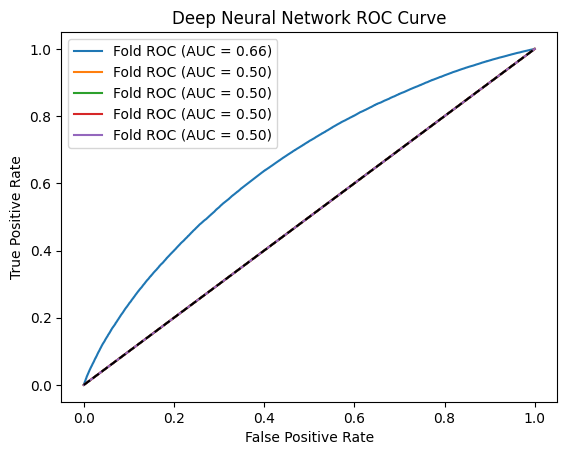

DNN Average Accuracy: 0.52
DNN Average ROC AUC: 0.53
DNN Average Precision: 0.33
DNN Average Recall: 0.51
DNN Average F1-Score: 0.39
DNN Confusion Matrix:
[[332992 291831]
 [303758 321065]]


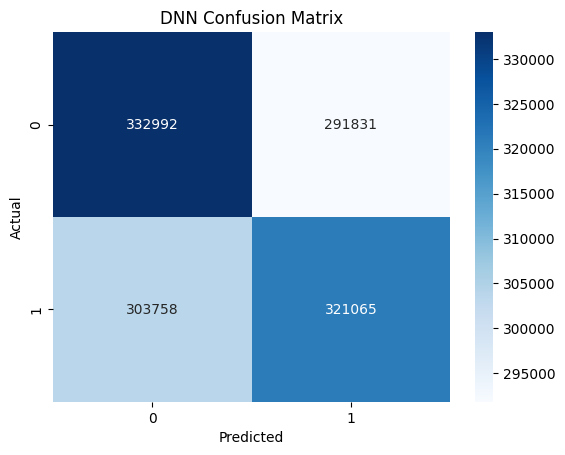

In [ ]:
# Initialize lists to store results
dnn_accuracy = []
dnn_roc_auc = []
dnn_precision = []
dnn_recall = []
dnn_f1 = []
dnn_conf_matrix = np.array([[0, 0], [0, 0]])

# Loop through the folds
for train_index, test_index in kf.split(X_train_res, y_train_res):
    X_train_fold, X_val_fold = X_train_res.iloc[train_index], X_train_res.iloc[test_index]
    y_train_fold, y_val_fold = y_train_res.iloc[train_index], y_train_res.iloc[test_index]

    # Build the DNN model
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_fold.shape[1],)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    model.fit(X_train_fold, y_train_fold, epochs=10, batch_size=32, verbose=0)

    # Predict
    y_pred_prob = model.predict(X_val_fold).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Calculate metrics
    dnn_accuracy.append(accuracy_score(y_val_fold, y_pred))
    dnn_roc_auc.append(roc_auc_score(y_val_fold, y_pred_prob))
    dnn_precision.append(precision_score(y_val_fold, y_pred))
    dnn_recall.append(recall_score(y_val_fold, y_pred))
    dnn_f1.append(f1_score(y_val_fold, y_pred))

    # Confusion matrix
    dnn_conf_matrix += confusion_matrix(y_val_fold, y_pred)

    # Plot ROC curve for each fold
    fpr, tpr, _ = roc_curve(y_val_fold, y_pred_prob)
    plt.plot(fpr, tpr, label=f'Fold ROC (AUC = {roc_auc_score(y_val_fold, y_pred_prob):.2f})')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Deep Neural Network ROC Curve')
plt.legend(loc='best')
plt.show()

# Output the average results
print(f'DNN Average Accuracy: {np.mean(dnn_accuracy):.2f}')
print(f'DNN Average ROC AUC: {np.mean(dnn_roc_auc):.2f}')
print(f'DNN Average Precision: {np.mean(dnn_precision):.2f}')
print(f'DNN Average Recall: {np.mean(dnn_recall):.2f}')
print(f'DNN Average F1-Score: {np.mean(dnn_f1):.2f}')
print(f'DNN Confusion Matrix:\n{dnn_conf_matrix}')

# Plot Confusion Matrix
sns.heatmap(dnn_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('DNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Import necessary libraries
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define your features (X) and target variable (y)
X = data[[ 'age', 'gender','cancer_stage', 'bmi', 'cholesterol_level', 'hypertension', 'asthma', 'cirrhosis', 'other_cancer', ]]
y = data['survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


# Check the distribution of the resampled training data
print("Training set after SMOTE:")
print(y_train_res.value_counts())

# Check the distribution of the original testing data
print("\nTesting set distribution:")
print(y_test.value_counts())


Training set after SMOTE:
survived
1    624823
0    624823
Name: count, dtype: int64

Testing set distribution:
survived
0    155718
1     44282
Name: count, dtype: int64


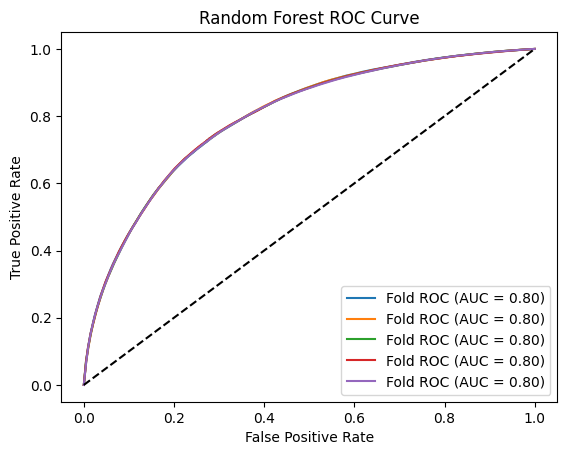

Random Forest Average Accuracy: 0.73
Random Forest Average ROC AUC: 0.80
Random Forest Average Precision: 0.72
Random Forest Average Recall: 0.74
Random Forest Average F1-Score: 0.73
Random Forest Confusion Matrix:
[[442763 182060]
 [159757 465066]]


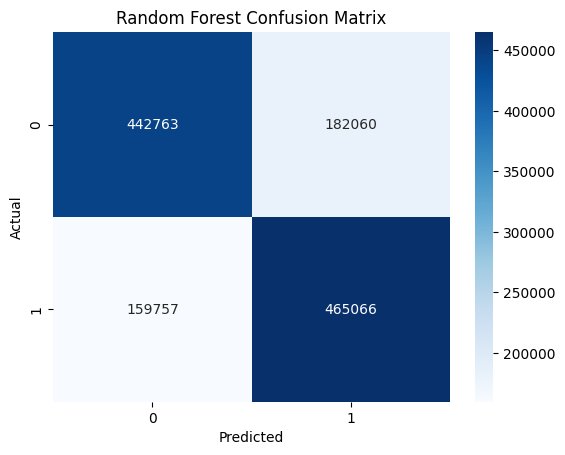

In [ ]:
# Initialize StratifiedKFold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store results
rf_accuracy = []
rf_roc_auc = []
rf_precision = []
rf_recall = []
rf_f1 = []
rf_conf_matrix = np.array([[0, 0], [0, 0]])

# Loop through the folds
for train_index, test_index in kf.split(X_train_res, y_train_res):
    X_train_fold, X_val_fold = X_train_res.iloc[train_index], X_train_res.iloc[test_index]
    y_train_fold, y_val_fold = y_train_res.iloc[train_index], y_train_res.iloc[test_index]

    # Initialize and train the RandomForestClassifier
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train_fold, y_train_fold)

    # Predict the labels
    y_pred = rf.predict(X_val_fold)
    y_pred_prob = rf.predict_proba(X_val_fold)[:, 1]

    # Append metrics for this fold
    rf_accuracy.append(accuracy_score(y_val_fold, y_pred))
    rf_roc_auc.append(roc_auc_score(y_val_fold, y_pred_prob))
    rf_precision.append(precision_score(y_val_fold, y_pred))
    rf_recall.append(recall_score(y_val_fold, y_pred))
    rf_f1.append(f1_score(y_val_fold, y_pred))

    # Update the confusion matrix
    rf_conf_matrix += confusion_matrix(y_val_fold, y_pred)

    # Plot ROC curve for each fold
    fpr, tpr, _ = roc_curve(y_val_fold, y_pred_prob)
    plt.plot(fpr, tpr, label=f'Fold ROC (AUC = {roc_auc_score(y_val_fold, y_pred_prob):.2f})')

# Plot settings for ROC curve
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc='best')
plt.show()

# Calculate and print average metrics
print(f'Random Forest Average Accuracy: {np.mean(rf_accuracy):.2f}')
print(f'Random Forest Average ROC AUC: {np.mean(rf_roc_auc):.2f}')
print(f'Random Forest Average Precision: {np.mean(rf_precision):.2f}')
print(f'Random Forest Average Recall: {np.mean(rf_recall):.2f}')
print(f'Random Forest Average F1-Score: {np.mean(rf_f1):.2f}')
print(f'Random Forest Confusion Matrix:\n{rf_conf_matrix}')

# Plot the Confusion Matrix
sns.heatmap(rf_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
# Import necessary libraries
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define your features (X) and target variable (y)
X = data[['treatment_type', 'family_history', 'smoking_status']]
y = data['survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


# Check the distribution of the resampled training data
print("Training set after SMOTE:")
print(y_train_res.value_counts())

# Check the distribution of the original testing data
print("\nTesting set distribution:")
print(y_test.value_counts())

Training set after SMOTE:
survived
1    624823
0    624823
Name: count, dtype: int64

Testing set distribution:
survived
0    155718
1     44282
Name: count, dtype: int64


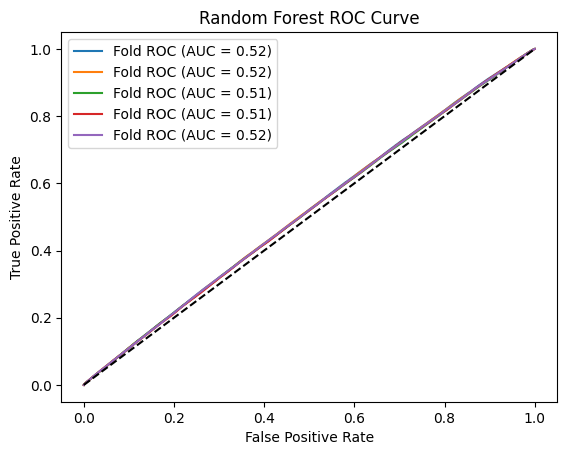

Random Forest Average Accuracy: 0.51
Random Forest Average ROC AUC: 0.52
Random Forest Average Precision: 0.51
Random Forest Average Recall: 0.52
Random Forest Average F1-Score: 0.51
Random Forest Confusion Matrix:
[[315548 309275]
 [302726 322097]]


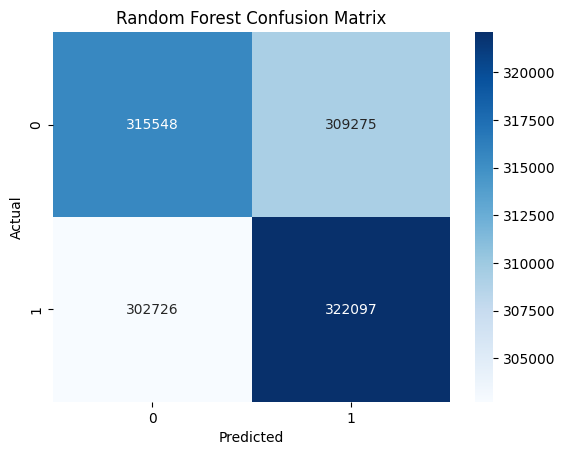

In [ ]:
# Initialize StratifiedKFold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store results
rf_accuracy = []
rf_roc_auc = []
rf_precision = []
rf_recall = []
rf_f1 = []
rf_conf_matrix = np.array([[0, 0], [0, 0]])

# Loop through the folds
for train_index, test_index in kf.split(X_train_res, y_train_res):
    X_train_fold, X_val_fold = X_train_res.iloc[train_index], X_train_res.iloc[test_index]
    y_train_fold, y_val_fold = y_train_res.iloc[train_index], y_train_res.iloc[test_index]

    # Initialize and train the RandomForestClassifier
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train_fold, y_train_fold)

    # Predict the labels
    y_pred = rf.predict(X_val_fold)
    y_pred_prob = rf.predict_proba(X_val_fold)[:, 1]

    # Append metrics for this fold
    rf_accuracy.append(accuracy_score(y_val_fold, y_pred))
    rf_roc_auc.append(roc_auc_score(y_val_fold, y_pred_prob))
    rf_precision.append(precision_score(y_val_fold, y_pred))
    rf_recall.append(recall_score(y_val_fold, y_pred))
    rf_f1.append(f1_score(y_val_fold, y_pred))

    # Update the confusion matrix
    rf_conf_matrix += confusion_matrix(y_val_fold, y_pred)

    # Plot ROC curve for each fold
    fpr, tpr, _ = roc_curve(y_val_fold, y_pred_prob)
    plt.plot(fpr, tpr, label=f'Fold ROC (AUC = {roc_auc_score(y_val_fold, y_pred_prob):.2f})')

# Plot settings for ROC curve
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc='best')
plt.show()

# Calculate and print average metrics
print(f'Random Forest Average Accuracy: {np.mean(rf_accuracy):.2f}')
print(f'Random Forest Average ROC AUC: {np.mean(rf_roc_auc):.2f}')
print(f'Random Forest Average Precision: {np.mean(rf_precision):.2f}')
print(f'Random Forest Average Recall: {np.mean(rf_recall):.2f}')
print(f'Random Forest Average F1-Score: {np.mean(rf_f1):.2f}')
print(f'Random Forest Confusion Matrix:\n{rf_conf_matrix}')

# Plot the Confusion Matrix
sns.heatmap(rf_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
